(1041, 2071)
max ev: 19.408975736238933, number above threshold: 8
7.030557356647205


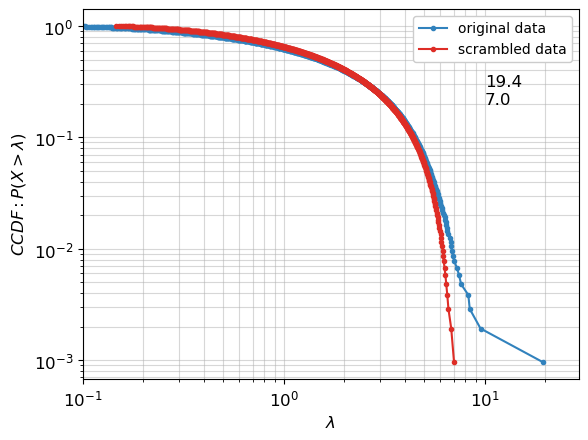

In [19]:
import src.analysis_functions as af
import src.data_functions as data_func
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import importlib



importlib.reload(af)
importlib.reload(data_func)

fsize=12

def get_data_for_plot(path, norm=True, log=False, norm_method='sum', norm_sum=1):
    # get annotated matrix from file
    amat = data_func.read_from_csv(path)
    # calculate the eigenvalues and plot:
    # remove tracker genes from the matrix
    t_genes = ['16s_mature', '16s_unprocessed']
    # amat.reset_filters()
    index = [np.where(amat.var_names == val)[0][0] for val in t_genes if val in amat.var_names]
    # filter the genes
    amat.filtered_var[np.array(index).astype(int)] = False
    m = amat.get_filtered_matrix().m
    pcs, pcs1, fraction_non_zeros = af.get_eig_dist(m, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
    return pcs, pcs1, m.shape[0], fraction_non_zeros

def plot_eigvals(ax, pcs, pcs1, N, x_max, y_max, n_bins, x_label=True, y_label=True):
    # plot the eigenvalue distribution of the normalized filtered matrix
    # define limits and bin number
    P = len(pcs)
    scale = 1  # scale factor for the Marchenko-Pastur distribution
    edges = np.linspace(-0.1, x_max, num=n_bins)

    # remove zeros in pcs and pcs1
    # if alpha>1 adjust the scale factor to match theoretical results
    if P / N > 1:
        scale = N / P
        pcs = pcs[pcs != 0]
        pcs1 = pcs1[pcs1 != 0]

    # first plot
    counts, bins = np.histogram(pcs, bins=edges, density=True)
    ax.plot(bins[1:], scale * counts, color='#3182bd', linewidth=1, label='original data')
    ax.fill_between(bins[1:], scale * counts, 0, color='#9ecae1', alpha=.4)
    # second plot
    counts, bins = np.histogram(pcs1, bins=edges, density=True)
    ax.plot(bins[1:], scale * counts, color='#de2d26', linewidth=1, label='scrambled data')
    ax.fill_between(bins[1:], scale * counts, 0, color='#fc9272', alpha=.4)
    # plot analytical Marchenko-Pastur distribution
    x = np.linspace(-0.1, x_max, 100)
    y = [af.mp_distribution(val, P / N) for val in x]
    ax.plot(x, y, color='#756bb1', linestyle='dashed', label='MP')
    # labels and limits
    if x_label:
        ax.set_xlabel("$\lambda$", fontsize=fsize)
    if y_label:
        ax.set_ylabel(r"$\rho(\lambda)$", fontsize=fsize)
    ax.set_ylim(0, y_max)
    ax.set_xlim(0, x_max)
    # set x_ticks with difference of 2
    ax.set_xticks(np.arange(0, (x_max // 2) * 2 + 2, 2))
    # set y_ticks with difference of 0.1
    ax.set_yticks(np.arange(0, (y_max // 0.1) * 0.1 + 0.1, 0.1))
    ax.legend(facecolor='white', framealpha=1, fontsize=fsize-2, loc='upper right')
    # set the font size of the ticks
    ax.tick_params(axis='both', which='major', labelsize=fsize)

def plot_eigvals_ccdf(ax, pcs, pcs1, N, x_label=True, y_label=True):
        # plot the eigenvalue distribution of the normalized filtered matrix
    # define limits and bin number
    pcs = pcs[pcs > 0]
    pcs1 = pcs1[pcs1 > 0]
    p = len(pcs)
    if p != len(pcs1):
        print('pcs1 must have same length as pcs')
    # 1. Sort the data in ascending order
    pcs = np.sort(pcs)
    pcs1 = np.sort(pcs1)

    # 2. Calculate the CDF values (from 1/N to 1)
    # n is the number of data points
    cdf = np.arange(1, p + 1) / p
    # 3. Calculate the CCDF (1 - CDF)
    ccdf = 1 - cdf + (1/p)

    # 4. Plotting
    ax.loglog(pcs, ccdf, marker='.', linestyle='-',color='#3182bd', label='original data')
    ax.loglog(pcs1, ccdf, marker='.',linestyle='-', color='#de2d26', label='scrambled data')
    ax.grid(True, which="both", ls="-", alpha=0.5)

    ax.set_xlim(1e-1, np.max(pcs)+10)
    # labels and limits
    if x_label:
        ax.set_xlabel("$\lambda$", fontsize=fsize)
    if y_label:
        ax.set_ylabel(r"$CCDF: P(X>\lambda)$", fontsize=fsize)

    ax.legend(facecolor='white', framealpha=1, fontsize=fsize-2, loc='upper right')
    # set the font size of the ticks
    ax.tick_params(axis='both', which='major', labelsize=fsize)


nbins = 81
x_max = 20
y_max = 0.3
fig, ax = plt.subplots()
# plot individual distributions
norm = True
log = False
norm_method = 'sum'
norm_sum = 1
# set style to default
plt.style.use('default')
plt.rcParams.update({'font.size': fsize})
# create grid of experimental results
# subplot 1
# get annotated matrix from file
root_dir = r"C:\Users\owner\Documents\Projects\dysregulated-persistence"
file_name = 'sample_2b_filtered.csv'
path = os.path.join(root_dir,'data_for_paper', file_name)
pcs, pcs1, N, fraction = get_data_for_plot(path, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
ax.text(10,0.2,f'{np.max(pcs):.1f}\n{np.max(pcs1):.1f}')
plot_eigvals_ccdf(ax,pcs, pcs1, N)
print(f'max ev: {np.max(pcs)}, number above threshold: {sum(pcs>np.max(pcs1))}')
print(np.max(pcs1))

In [136]:
print(pcs[:10])
print(pcs1[:10])


[17.15869287 15.48419304 11.74029514 11.12994179  7.9855012   7.84056874
  7.73266457  7.70994074  7.37160864  6.71627641]
[18.43834109 16.36287608 12.62976302 12.23448086  9.61517102  9.27882905
  8.91772957  8.74383302  8.40753467  8.13962839]


0 zeros:38
0.980805582761998


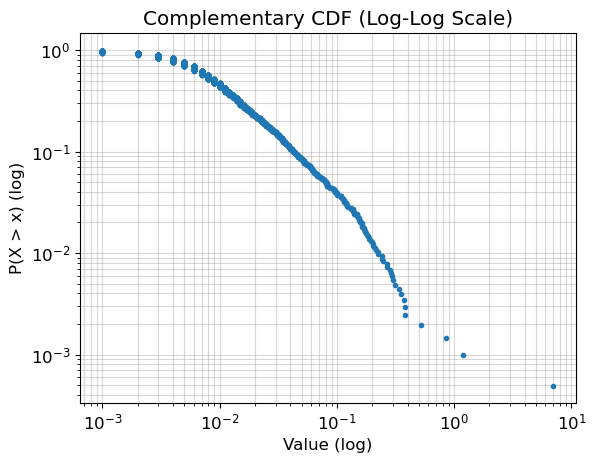

In [30]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
root_dir = r"C:\Users\owner\Documents\Projects\dysregulated-persistence"
file_name = ('sample_15a_filtered.csv')
path = os.path.join(root_dir,'data_for_paper', file_name)
df = pd.read_csv(os.path.join(root_dir,'data_for_paper', file_name), index_col=0, header=0)
m = df.to_numpy()
gene_sums = m.mean(axis=0)
def plot_ccdf(data, label=None):
    # 1. Sort the data in ascending order
    sorted_data = np.sort(data)

    # 2. Calculate the CDF values (from 1/N to 1)
    # n is the number of data points
    n = len(sorted_data)
    cdf = np.arange(1, n + 1) / n

    # 3. Calculate the CCDF (1 - CDF)
    # We use (n - i) / n to avoid the last point being 0,
    # which can't be plotted on a log scale.
    ccdf = 1 - cdf + (1/n)

    # 4. Plotting
    plt.loglog(sorted_data, ccdf, marker='.', linestyle='none', label=label)
    plt.xlabel('Value (log)')
    plt.ylabel('P(X > x) (log)')
    plt.title('Complementary CDF (Log-Log Scale)')
    plt.grid(True, which="both", ls="-", alpha=0.5)
plot_ccdf(gene_sums)
print(f'0 zeros:{np.sum(gene_sums == 0)}')
print(sum(sum(m==0))/len(m.flatten()))

In [21]:
import src.analysis_functions as af
import src.data_functions as data_func
import os
import importlib
importlib.reload(af)
importlib.reload(data_func)

#parameters:
norm = True
log = False
norm_method = 'sum'
norm_sum = 1
path = r'C:\Users\owner\Documents\Projects\dysregulated-persistence\data_for_paper'
file_data = []
for file in os.listdir(path):
    file_name = os.path.join(path, file)
    pcs, pcs1, N, fraction_non_zeros = get_data_for_plot(file_name, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
    max_ev = np.max(pcs)
    max_ev_scrambled = np.max(pcs1)
    entropy = af.get_entropy(pcs)
    entropy_scrambled = af.get_entropy(pcs1)
    file_data.append({
                'file_name': file,
                'max_ev': max_ev,
                'max_ev_scrambled': max_ev_scrambled,
                'eig_diff': max_ev - max_ev_scrambled,
                'sum_denoised_ev': np.sum(pcs[pcs>max_ev_scrambled]),
                'fraction_non-zero': fraction_non_zeros,
            })
data = pd.DataFrame(file_data)
category = ['r','r','d','r','d','r','r','d','d','d','d','r','r','r','d']
data['category'] = category

data

(1994, 3973)
(994, 1997)
(1000, 2037)
(1000, 2023)
(1000, 2004)
(1000, 2023)
(1041, 2071)
(967, 1997)
(948, 1998)
(1000, 1997)
(1001, 1998)
(900, 1797)
(898, 1797)
(895, 1798)
(898, 1797)


,file_name,max_ev,max_ev_scrambled,eig_diff,sum_denoised_ev,fraction_non-zero,category
0,adam_matrix_filtered.csv,11.249618,5.977529,5.272089,176.513317,0.046594,r
1,Expira_biorep_t0A_filtered.csv,17.158693,6.704513,10.454179,100.869683,0.023606,r
2,sample_13a_filtered.csv,8.242494,6.699084,1.543410,22.257151,0.031008,d
3,sample_13b_filtered.csv,14.258587,6.538469,7.720119,107.298741,0.029205,r
4,sample_15a_filtered.csv,6.094979,6.598790,-0.503811,0.000000,0.019558,d
5,sample_15b_filtered.csv,17.281707,6.283891,10.997816,162.254968,0.043217,r
6,sample_2b_filtered.csv,19.408976,6.103762,13.305214,178.917412,0.048638,r
7,SHX_biorep2A.csv,9.502631,6.335498,3.167133,119.964905,0.026887,d
8,SHX_biorep2B.csv,7.650878,6.450328,1.200550,14.215131,0.024629,d
9,SHX_biorep4A.csv,8.332470,5.862599,2.469872,20.941054,0.029388,d


In [232]:
from scipy import stats
dis = data['sum_denoised_ev'].loc[data['category'] == 'd']
reg = data['sum_denoised_ev'].loc[data['category'] == 'r']
u_stat, p_value = stats.mannwhitneyu(dis, reg, alternative='less')

print(f"U-statistic: {u_stat}")
print(f"P-value: {p_value}")

U-statistic: 15.0
P-value: 0.075990675990676


PearsonRResult(statistic=0.3149880716270876, pvalue=0.2528228388071776)

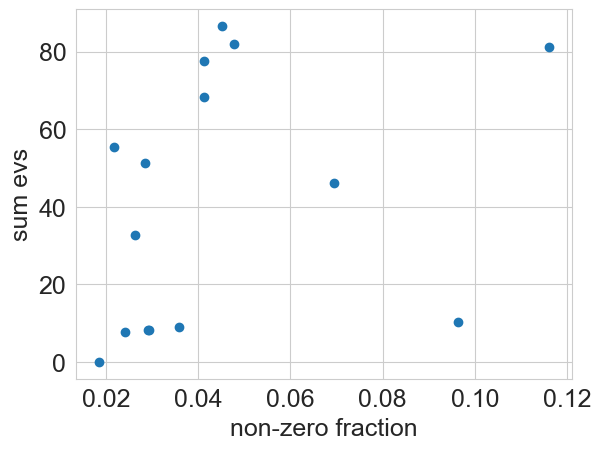

In [26]:
import scipy.stats as stats
data = pd.read_csv(r"C:\Users\owner\Documents\Projects\dysregulated-persistence\results\data_metrics\test3.csv")
x = data['sum_denoised_ev']
y = data['fraction_non-zero']
plt.scatter(y,x)
plt.xlabel('non-zero fraction')
plt.ylabel('sum evs')
res = stats.pearsonr(y,x)
res

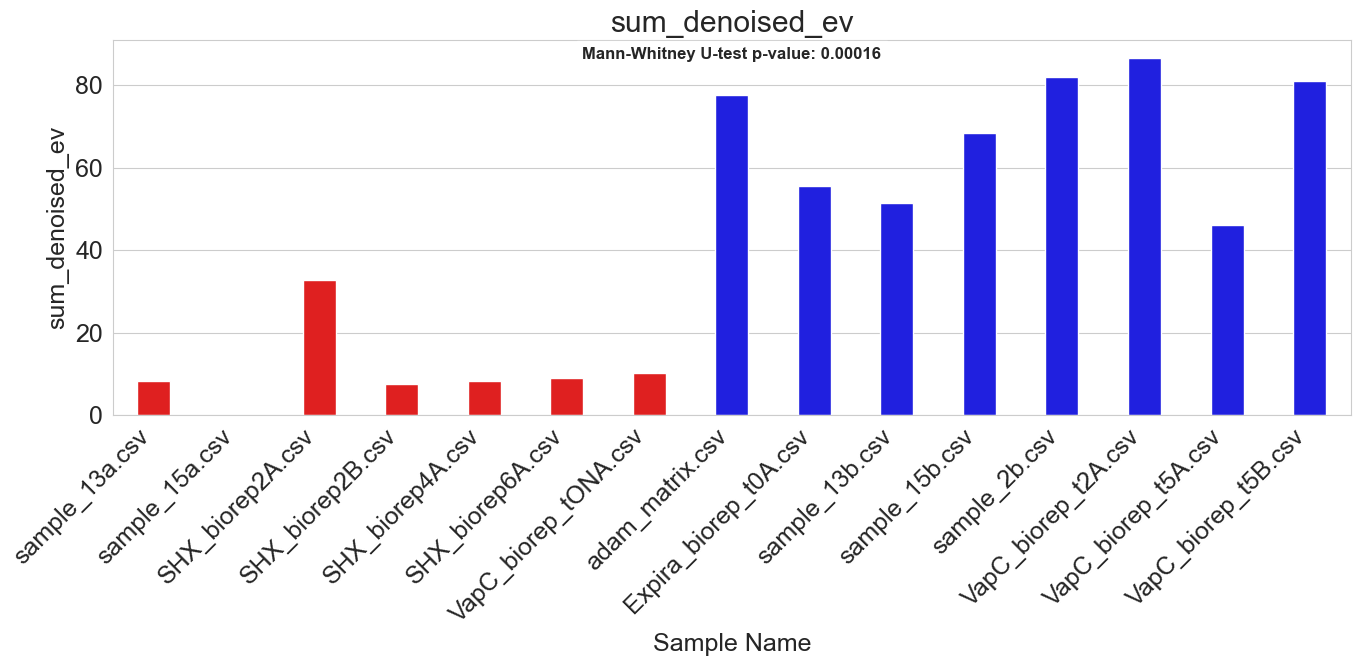

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def plot_custom_bars(file_path, column_to_plot):
    # 1. Load the dataset
    df = pd.read_csv(file_path)

    # 2. Clean sample names (remove '_filtered')
    df['sample_name'] = df['file_name'].str.replace('_filtered', '', regex=False)

    # 3. Sort by category for grouping
    df_sorted = df.sort_values(by='category').reset_index(drop=True)

    # 4. Perform Mann-Whitney U-test
    # Targeting 'd' vs 'r' specifically
    group_d = df_sorted[df_sorted['category'] == 'd'][column_to_plot]
    group_r = df_sorted[df_sorted['category'] == 'r'][column_to_plot]
    stat, p_val = mannwhitneyu(group_d, group_r, alternative='less')

    # 5. Plotting
    plt.figure(figsize=(14, 7))

    # Custom colors: d = red, r = blue
    custom_palette = {'d': 'red', 'r': 'blue'}

    # width=0.4 makes bars thinner; dodge=False keeps them on the category labels
    ax = sns.barplot(
        data=df_sorted,
        x='sample_name',
        y=column_to_plot,
        hue='category',
        palette=custom_palette,
        dodge=False,
        width=0.4
    )

    # 6. Remove the legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # 7. Labels and Formatting
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{column_to_plot}')
    plt.xlabel('Sample Name')
    plt.ylabel(column_to_plot)

    # Add Mann-Whitney U-test result to the top of the plot
    plt.text(0.5, 0.95, f'Mann-Whitney U-test p-value: {p_val:.5f}',
             horizontalalignment='center', transform=plt.gca().transAxes,
             fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# Example usage with your data
plot_custom_bars(r"C:\Users\owner\Documents\Projects\dysregulated-persistence\results\data_metrics\test3.csv", 'sum_denoised_ev')

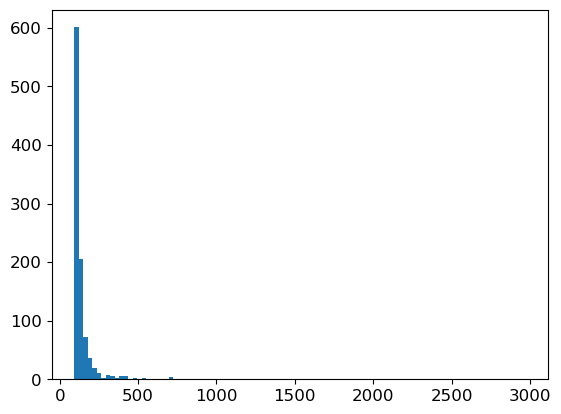

In [281]:
root_dir = r"C:\Users\owner\Documents\Projects\dysregulated-persistence"
file_name = 'Expira_biorep_t0A_filtered.csv'
path = os.path.join(root_dir,'data_for_paper', file_name)
amat = data_func.read_from_csv(os.path.join(root_dir,'data_for_paper', file_name))
mat = amat.m
#plot_ccdf(np.sum(mat, axis=1))
plt.hist(np.sum(mat, axis=1),bins=100)
plt.show()

In [284]:
'fliC' in amat.var_names

False

<Axes: >

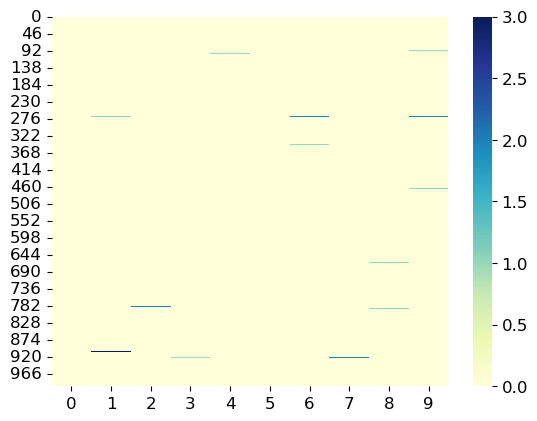

In [269]:
import seaborn as sns
root_dir = r"C:\Users\owner\Documents\Projects\dysregulated-persistence"
file_name = 'sample_15b_filtered.csv'
path = os.path.join(root_dir,'data_for_paper', file_name)
amat = data_func.read_from_csv(path)
m = amat.m
gene_sums = m.sum(axis=0)
gene_std = m.std(axis=0)
m = m[:,np.logical_and(gene_sums > 0,gene_sums <5)]
raw = m.copy()
m = (m-m.mean(axis=0))/m.std(axis=0)
#m
corr_matrix = m.T @ m / m.shape[0]
#sns.clustermap(corr_matrix, annot=False, cmap='vlag', center=0, linewidths=.5)
eigs = np.linalg.eig(corr_matrix)
np.max(eigs[0])
sns.heatmap(raw, cmap='YlGnBu')
